In [5]:
# Import required packages
import openeo
from openeo.processes import process

<h2>Login to Copernicus Dataspace: <a href="https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/auth?client_id=cdse-public&response_type=code&scope=openid&redirect_uri=https%3A//dataspace.copernicus.eu/account/confirmed/1" target="_blank">link</a></h2>

In [6]:
# Connect to the back-end
connection = openeo.connect("https://openeosh.dataspace.copernicus.eu/")

In [7]:
connection.authenticate_oidc()

Authenticated using refresh token.


<Connection to 'https://openeosh.dataspace.copernicus.eu/1.2' with OidcBearerAuth>

In [20]:
load2 = connection.load_collection(collection_id = "SENTINEL2_L1C_SENTINELHUB", spatial_extent = {"west": 14.503132250376241, "south": 45.98989222284457, "east": 14.578437275398317, "north": 46.04381770188389, "width": 1250, "height": 1250}, temporal_extent = ["2022-03-26T00:00:00Z", "2022-03-26T23:59:59Z"], bands = ["B02", "B03", "B04"])


In [31]:
def sAdj(x, context = None):
    divide2 = x / 3 # x / MaxR
    ar = process("clip", x = divide2, min = 0, max = 1) # ar
    
    mima = 0.13 / 3 # midR/maxR
    multiply1 = ar * (2 * mima -1) # (ar * (2 * midR/maxR - 1)
    divisor = multiply1 - mima # (ar * (2 * midR/maxR - 1) - midR/maxR)
    dividend = ar * (ar * mima - 1) # ar * (ar * (midR/maxR) - 1)

    adj = dividend / divisor # (ar * (ar * (midR/maxR) - 1)) / (ar * (2 * midR/maxR - 1) - midR/maxR)
    gOffPow = 0.01**2.3
    power1 = 1.1**2.3
    gOffRange = power1 - gOffPow # (1+gOff)^gamma - gOffPow
    
    subtract3 = (adj + 0.01)**2.3 - gOffPow # ((adj + gOff)^gamma)-gOffPow
    adjGamma = subtract3 / gOffRange # sAdj
    return adjGamma

In [32]:
def process1(data, context = None):
    arrayB2 = data[2] - 0.041
    arrayB3 = data[1] - 0.024
    arrayB4 = data[0] - 0.013
    array1 = process("array_create", data = [sAdj(arrayB2), sAdj(arrayB3), sAdj(arrayB4)])
    return array1

In [33]:
apply1 = load2.apply_dimension(dimension = "bands", process = process1)

In [34]:
def sRGB(x, context = None):
    accept = x * 12.92 # (12.92 * x)
    power1 = x**0.41666666666
    reject = power1 * 1.055 - 0.055  # 1.055 * x^0.41666666666
    
    lte2 = process("lte", x = x, y = 0.0031308) # c <= 0.0031308
    if1 = process("if", value = lte2, accept = accept, reject = reject)
    return if1

In [35]:
def satEnh(data, context = None):
    r = data[2] # r
    g = data[1] # g
    b = data[0] # b
    
    rsat = 6.5 * r # r * sat
    gsat = 6.5 * g # g * sat
    bsat = 6.5 * b # b* sat
    subtract3 = 1 - 1.3 # (1 - sat)
    
    sum = r + g + b # (r + g + b)
    avg = sum / 3 # (r + g + b)/3
    
    avgS = subtract3 * avg  # (1 - sat) * ((r + g + b) / 3.0) 
    sum1 = rsat + avgS # r * sat + avgS
    sum2 = gsat + avgS # g * sat + avgS
    sum3 = bsat + avgS # b * sat + avgS
    
    clip1 = process("clip", x = sum1, min = 0, max = 1) # clip(avgS + r * sat)
    clip2 = process("clip", x = sum2, min = 0, max = 1) # clip(avgS + g * sat)
    clip3 = process("clip", x = sum3, min = 0, max = 1) # clip(avgS + b * sat)
    
    # satEnh(sAdj(smp.B04), sAdj(smp.B03), sAdj(smp.B02))
    array1 = process("array_create", data = [sRGB(clip1), sRGB(clip2), sRGB(clip3)])
    return array1


In [36]:
# satEnh
apply2 = apply1.apply_dimension(dimension = "bands", process = satEnh)

In [37]:
save5 = apply2.save_result(format = "jpeg")

In [38]:
print(save5.to_json())

{
  "process_graph": {
    "loadcollection1": {
      "process_id": "load_collection",
      "arguments": {
        "bands": [
          "B02",
          "B03",
          "B04"
        ],
        "id": "SENTINEL2_L1C_SENTINELHUB",
        "spatial_extent": {
          "west": 14.503132250376241,
          "south": 45.98989222284457,
          "east": 14.578437275398317,
          "north": 46.04381770188389,
          "width": 1250,
          "height": 1250
        },
        "temporal_extent": [
          "2022-03-26T00:00:00Z",
          "2022-03-26T23:59:59Z"
        ]
      }
    },
    "applydimension1": {
      "process_id": "apply_dimension",
      "arguments": {
        "data": {
          "from_node": "loadcollection1"
        },
        "dimension": "bands",
        "process": {
          "process_graph": {
            "arrayelement1": {
              "process_id": "array_element",
              "arguments": {
                "data": {
                  "from_parameter": "data

In [39]:
save5.download("niceColor.jpeg")

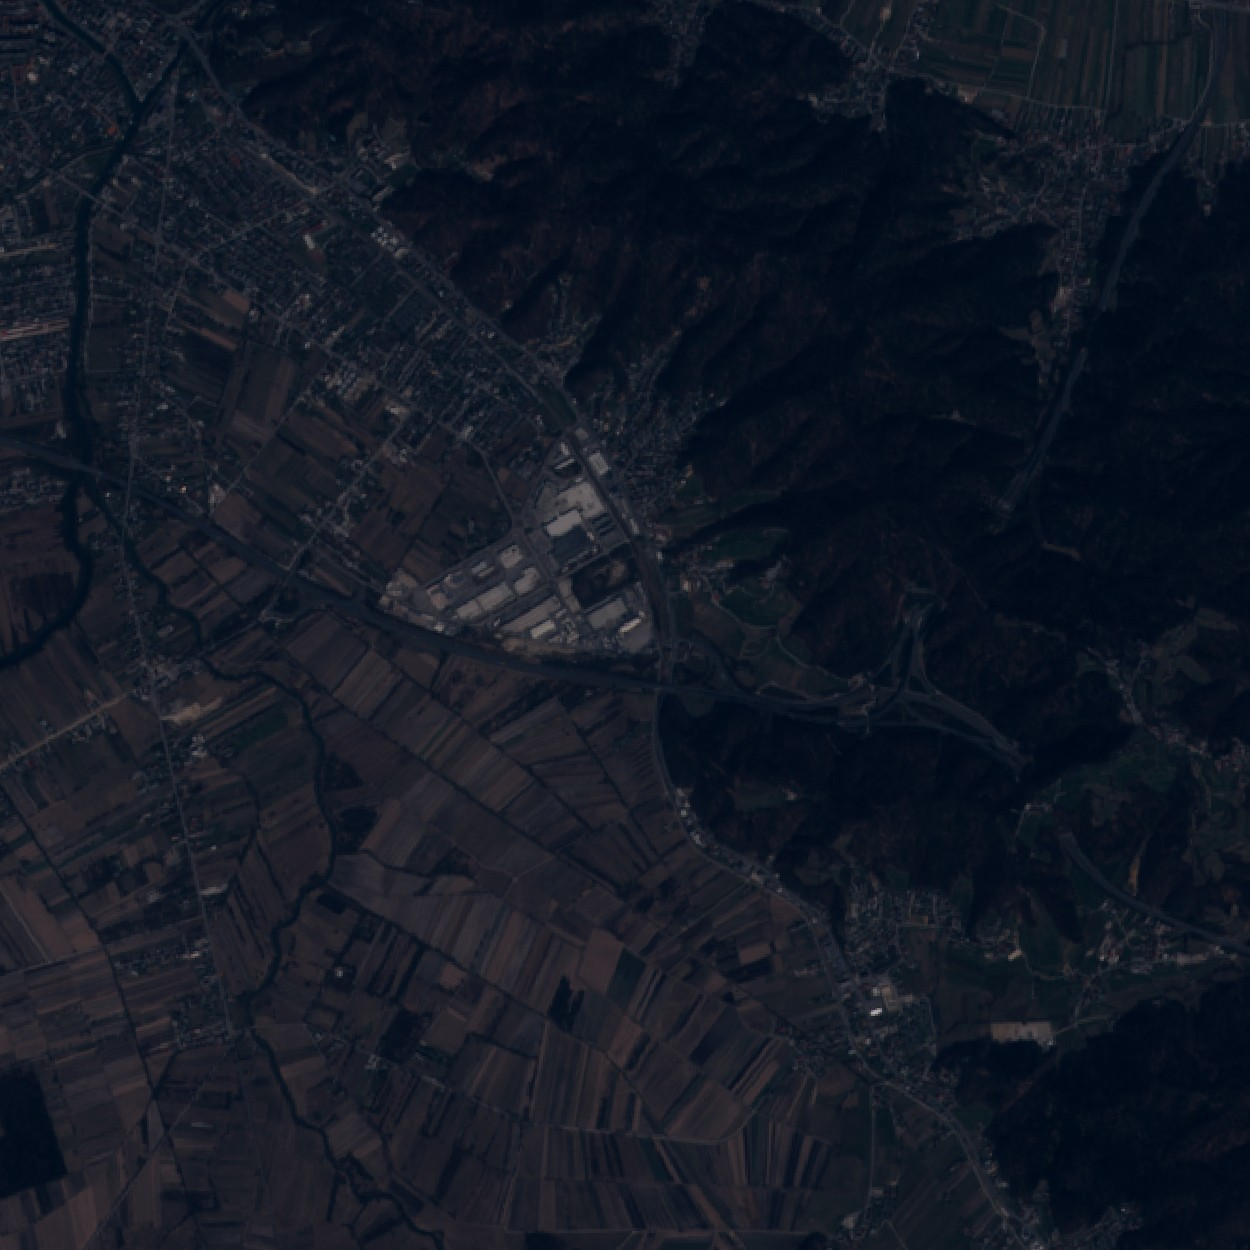

In [40]:
from IPython.display import Image
Image(filename='niceColor.jpeg') 